# Predict machine failure risk and decide what to inspect next

This notebook uses a machine failure sensor dataset to answer one operating question: which machines should be inspected next.

Unlike the baseline notebook, this version moves from prediction to prioritization. It ranks machines by failure risk, chooses a practical operating cutoff, turns the ranked output into an inspection queue, and shows what limited review capacity changes.

## Goal

Predict which machines are most likely to fail and use that ranking to decide what should be inspected first.

## What this notebook does

- Benchmarks a small set of models
- Keeps one selected model
- Chooses an operating high risk cutoff from validation results
- Builds a ranked inspection queue on the holdout set
- Measures queue quality where action happens
- Compares capacity scenarios
- Converts the ranking into a simple triage rule

## What it does not do yet

- It does not model one machine through time
- It does not estimate exact failure timing
- It does not optimize maintenance scheduling or staffing
- It does not prove causal relationships between sensors and failure

This is a practical inspection decision notebook, not a full maintenance optimization system.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## Run settings

These values define the decision frame used in the notebook.

Some numbers below are policy inputs, not facts learned from the dataset. For example, inspection cost and missed failure loss are business assumptions used to compare operating choices.

In [2]:
target_column = "fail"
random_seed = 42

test_share = 0.20
validation_share = 0.20

daily_inspection_capacity = 10
inspection_capacity_options = [10, 20, 30, 40, 60]
expedite_slots = 5

inspection_cost_per_machine = 1.0
missed_failure_loss = 20.0
minimum_precision_for_high_risk = 0.90

data_path = Path(
    "/kaggle/input/datasets/patimejia/machine-failure-sensor-data-kaggle-cstefan/data.csv"
)

if not data_path.exists():
    raise FileNotFoundError("Could not find the uploaded machine failure dataset.")

print(f"Data path: {data_path}")

Data path: /kaggle/input/datasets/patimejia/machine-failure-sensor-data-kaggle-cstefan/data.csv


## Load and audit the data

Before modeling, check four basics.

First, the file loads.
Second, the target exists.
Third, missing values and duplicates are manageable.
Fourth, the failure rate is visible so the reader knows the base problem difficulty.

In [3]:
data = pd.read_csv(data_path)

print(f'Rows: {len(data):,}')
print(f'Columns: {data.shape[1]}')
print(f'Failure rate: {data[target_column].mean():.1%}')
print(f'Duplicate rows: {data.duplicated().sum():,}')

data_quality = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'missing_count': data.isna().sum(),
    'missing_pct': data.isna().mean().mul(100).round(2),
    'unique_values': data.nunique(),
})

data_quality

Rows: 944
Columns: 10
Failure rate: 41.6%
Duplicate rows: 1


,dtype,missing_count,missing_pct,unique_values
footfall,int64,0,0.000,99
tempMode,int64,0,0.000,8
AQ,int64,0,0.000,7
USS,int64,0,0.000,7
CS,int64,0,0.000,7
VOC,int64,0,0.000,7
RP,int64,0,0.000,71
IP,int64,0,0.000,7
Temperature,int64,0,0.000,24
fail,int64,0,0.000,2


## Prepare the modeling table

Each row represents one machine record.

A simple numeric machine identifier is added only to track rows through the queue. It is not used as a model feature. The model uses the sensor and operating fields only.

In [4]:
modeling_data = data.drop_duplicates().reset_index(drop=True)
modeling_data["machine_id"] = np.arange(1, len(modeling_data) + 1)

feature_columns = [
    column_name
    for column_name in modeling_data.columns
    if column_name not in {target_column, "machine_id"}
]

feature_table = modeling_data[feature_columns]
target_series = modeling_data[target_column].astype(int)
machine_id_series = modeling_data["machine_id"]

(
    X_train_full,
    X_test,
    y_train_full,
    y_test,
    _,
    ids_test,
) = train_test_split(
    feature_table,
    target_series,
    machine_id_series,
    test_size=test_share,
    stratify=target_series,
    random_state=random_seed,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=validation_share,
    stratify=y_train_full,
    random_state=random_seed,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_validation), len(X_test)],
        "failure_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    }
)

split_summary

,split,rows,failure_rate
0,train,603,0.416
1,validation,151,0.417
2,test,189,0.418


## Benchmark a small set of models

This project does not need a large model zoo.

A small benchmark is enough to answer the business question. We compare three common models, then keep one winning model for the rest of the notebook.

In [5]:
def build_model_pipeline(model_name):
    if model_name == "Logistic Regression":
        model = LogisticRegression(max_iter=2000, random_state=random_seed)
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model),
            ]
        )

    if model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=3,
            random_state=random_seed,
            n_jobs=-1,
        )
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("model", model),
            ]
        )

    if model_name == "Gradient Boosting":
        model = GradientBoostingClassifier(random_state=random_seed)
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("model", model),
            ]
        )

    raise ValueError(f"Unknown model: {model_name}")


candidate_model_names = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
]

benchmark_rows = []
fitted_model_map = {}

for model_name in candidate_model_names:
    model_pipeline = build_model_pipeline(model_name)
    model_pipeline.fit(X_train, y_train)
    validation_probability = model_pipeline.predict_proba(X_validation)[:, 1]

    benchmark_rows.append(
        {
            "model": model_name,
            "average_precision": average_precision_score(y_validation, validation_probability),
            "roc_auc": roc_auc_score(y_validation, validation_probability),
            "brier_score": brier_score_loss(y_validation, validation_probability),
        }
    )
    fitted_model_map[model_name] = model_pipeline

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["average_precision", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

benchmark_table

,model,average_precision,roc_auc,brier_score
0,Gradient Boosting,0.929,0.934,0.118
1,Logistic Regression,0.929,0.931,0.114
2,Random Forest,0.922,0.925,0.101


## Keep one winning model

From this point forward, the notebook uses only the best validation model. This keeps the story focused and prevents duplicate queue logic later.

In [6]:
selected_model_name = benchmark_table.loc[0, 'model']
selected_model = fitted_model_map[selected_model_name]

print(f'Selected model: {selected_model_name}')

Selected model: Gradient Boosting


## Choose the operating high risk cutoff

The model outputs probabilities, but the queue still needs a practical operating cutoff.

This notebook sets that cutoff using validation results, not test results. The rule is simple: keep only cutoffs that meet the minimum precision target, then choose the one with the best recall within that set.

This cutoff is an operating choice. It does not mean machines above the line are guaranteed to fail.

In [7]:
validation_probability = selected_model.predict_proba(X_validation)[:, 1]
precision_values, recall_values, cutoff_values = precision_recall_curve(y_validation, validation_probability)

cutoff_table = pd.DataFrame({
    'cutoff': cutoff_values,
    'precision': precision_values[:-1],
    'recall': recall_values[:-1],
})

valid_cutoff_table = cutoff_table[
    cutoff_table['precision'] >= minimum_precision_for_high_risk
].copy()

if valid_cutoff_table.empty:
    selected_cutoff_row = cutoff_table.sort_values(
        ['precision', 'recall', 'cutoff'],
        ascending=[False, False, True],
    ).iloc[0]
else:
    selected_cutoff_row = valid_cutoff_table.sort_values(
        ['recall', 'precision', 'cutoff'],
        ascending=[False, False, True],
    ).iloc[0]

operating_high_risk_cutoff = float(selected_cutoff_row['cutoff'])

cutoff_summary = pd.DataFrame({
    'item': [
        'Selected model',
        'Operating high risk cutoff',
        'Validation precision at cutoff',
        'Validation recall at cutoff',
    ],
    'value': [
        selected_model_name,
        operating_high_risk_cutoff,
        float(selected_cutoff_row['precision']),
        float(selected_cutoff_row['recall']),
    ],
})

cutoff_summary

,item,value
0,Selected model,Gradient Boosting
1,Operating high risk cutoff,0.925
2,Validation precision at cutoff,0.925
3,Validation recall at cutoff,0.778


## Build one ranked inspection queue

The queue is the center of the notebook.

Every test machine gets a predicted failure probability. The queue then sorts machines from highest risk to lowest risk. All later sections reuse this same queue.

In [8]:
test_probability = selected_model.predict_proba(X_test)[:, 1]

risk_queue = pd.DataFrame({
    'machine_id': ids_test.values,
    'predicted_failure_probability': test_probability,
    'actual_failure': y_test.values,
})

risk_queue = risk_queue.sort_values(
    'predicted_failure_probability',
    ascending=False,
).reset_index(drop=True)

risk_queue['queue_rank'] = risk_queue.index + 1
risk_queue['is_high_risk'] = (
    risk_queue['predicted_failure_probability'] >= operating_high_risk_cutoff
)

high_risk_machine_count = int(risk_queue['is_high_risk'].sum())
high_risk_failures_in_holdout = int(
    risk_queue.loc[risk_queue['is_high_risk'], 'actual_failure'].sum()
)

print(f'Machines in the high risk pool: {high_risk_machine_count}')
print(f'Labeled failures inside that pool in the holdout sample: {high_risk_failures_in_holdout}')

risk_queue.head(15)

Machines in the high risk pool: 65
Labeled failures inside that pool in the holdout sample: 62


,machine_id,predicted_failure_probability,actual_failure,queue_rank,is_high_risk
0,885,0.998,1,1,True
1,914,0.998,1,2,True
2,848,0.998,1,3,True
3,445,0.997,1,4,True
4,411,0.997,1,5,True
5,841,0.997,1,6,True
6,524,0.996,1,7,True
7,611,0.996,1,8,True
8,480,0.996,1,9,True
9,668,0.996,1,10,True


## Test the locked operating rule once on unseen data

These test metrics are retrospective evaluation on unseen holdout data. They are useful for judging queue quality, but they are not future certainty.

In [9]:
test_predicted_high_risk = (test_probability >= operating_high_risk_cutoff).astype(int)

test_summary_metrics = pd.DataFrame({
    'metric': [
        'Average precision',
        'ROC AUC',
        'Brier score',
        'High risk precision',
        'High risk recall',
    ],
    'value': [
        average_precision_score(y_test, test_probability),
        roc_auc_score(y_test, test_probability),
        brier_score_loss(y_test, test_probability),
        precision_score(y_test, test_predicted_high_risk, zero_division=0),
        recall_score(y_test, test_predicted_high_risk, zero_division=0),
    ],
})

test_summary_metrics

,metric,value
0,Average precision,0.961
1,ROC AUC,0.970
2,Brier score,0.061
3,High risk precision,0.954
4,High risk recall,0.785


## Check whether the probabilities are directionally sensible

This is a light calibration check.

It asks whether higher predicted risk generally lines up with higher observed failure rates. It is only a directional check, not a full calibration study.

In [10]:
calibration_view = pd.DataFrame({
    'predicted_failure_probability': test_probability,
    'actual_failure': y_test.values,
}).sort_values('predicted_failure_probability').reset_index(drop=True)

calibration_view['risk_decile'] = pd.qcut(
    pd.Series(np.arange(len(calibration_view))),
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
)

calibration_table = (
    calibration_view.groupby('risk_decile', observed=False)
    .agg(
        average_predicted_risk=('predicted_failure_probability', 'mean'),
        observed_failure_rate=('actual_failure', 'mean'),
        machine_count=('actual_failure', 'size'),
    )
    .reset_index()
)

calibration_table

,risk_decile,average_predicted_risk,observed_failure_rate,machine_count
0,D1,0.002,0.000,19
1,D2,0.005,0.000,19
2,D3,0.011,0.053,19
3,D4,0.026,0.000,19
4,D5,0.077,0.053,19
5,D6,0.411,0.389,18
6,D7,0.864,0.842,19
7,D8,0.974,0.895,19
8,D9,0.991,0.947,19
9,D10,0.996,1.000,19


## Show what mostly drives the ranking

A queue is easier to trust when the reader can see which variables matter most.

The values below show relative influence inside the selected model. They show which inputs helped shape the ranking, not a claim of direct causation.

In [11]:
selected_model_core = selected_model.named_steps['model']

if hasattr(selected_model_core, 'feature_importances_'):
    feature_importance_table = pd.DataFrame({
        'feature': feature_columns,
        'importance': selected_model_core.feature_importances_,
    })
else:
    feature_importance_table = pd.DataFrame({
        'feature': feature_columns,
        'importance': np.abs(selected_model_core.coef_[0]),
    })

feature_importance_table = feature_importance_table.sort_values('importance', ascending=False)
feature_importance_table

,feature,importance
5,VOC,0.773
3,USS,0.072
8,Temperature,0.040
2,AQ,0.032
4,CS,0.032
0,footfall,0.025
6,RP,0.016
1,tempMode,0.007
7,IP,0.004


## Measure queue quality where action happens

The top of the queue matters more than overall averages because real teams inspect a limited number of machines.

Precision at top k shows how concentrated failures are in the inspected group. Recall at top k shows how many failures the team would catch. Lift compares that precision to random inspection.

In [12]:
base_failure_rate = risk_queue["actual_failure"].mean()
total_holdout_failures = int(risk_queue["actual_failure"].sum())

queue_quality_rows = []

for inspection_count in inspection_capacity_options:
    if inspection_count > len(risk_queue):
        continue

    inspected_slice = risk_queue.head(inspection_count)
    failures_captured = int(inspected_slice["actual_failure"].sum())
    precision_at_k = inspected_slice["actual_failure"].mean()

    queue_quality_rows.append(
        {
            "inspections": inspection_count,
            "failures_captured": failures_captured,
            "precision_at_k": precision_at_k,
            "recall_at_k": (
                failures_captured / total_holdout_failures if total_holdout_failures else np.nan
            ),
            "lift_vs_random": (
                precision_at_k / base_failure_rate if base_failure_rate else np.nan
            ),
        }
    )

queue_quality_table = pd.DataFrame(queue_quality_rows)
queue_quality_table

,inspections,failures_captured,precision_at_k,recall_at_k,lift_vs_random
0,10,10,1.000,0.127,2.392
1,20,20,1.000,0.253,2.392
2,30,30,1.000,0.380,2.392
3,40,39,0.975,0.494,2.333
4,60,57,0.950,0.722,2.273


## Compare inspection capacity choices

This section shows what changes when inspection capacity increases.

It does not optimize staffing. It compares what gets inspected, what stays deferred, and how expected cost changes under the policy assumptions defined earlier.

In [13]:
def evaluate_capacity_option(queue_table, inspection_capacity):
    inspected_now = queue_table.head(inspection_capacity)
    remaining_backlog = queue_table.iloc[inspection_capacity:]

    captured_failures = int(inspected_now["actual_failure"].sum())
    deferred_failures = int(remaining_backlog["actual_failure"].sum())
    inspection_cost = inspection_capacity * inspection_cost_per_machine
    expected_missed_failure_cost = (
        remaining_backlog["predicted_failure_probability"].sum() * missed_failure_loss
    )

    return {
        "capacity": inspection_capacity,
        "actual_failures_captured": captured_failures,
        "actual_failures_deferred": deferred_failures,
        "precision_at_capacity": inspected_now["actual_failure"].mean(),
        "recall_at_capacity": (
            captured_failures / total_holdout_failures if total_holdout_failures else np.nan
        ),
        "high_risk_left_in_backlog": int(remaining_backlog["is_high_risk"].sum()),
        "inspection_cost": inspection_cost,
        "expected_missed_failure_cost_under_policy_assumptions": expected_missed_failure_cost,
        "total_expected_cost_under_policy_assumptions": (
            inspection_cost + expected_missed_failure_cost
        ),
    }


capacity_table = pd.DataFrame(
    [evaluate_capacity_option(risk_queue, capacity) for capacity in inspection_capacity_options]
)

capacity_table

,capacity,actual_failures_captured,actual_failures_deferred,precision_at_capacity,recall_at_capacity,high_risk_left_in_backlog,inspection_cost,expected_missed_failure_cost_under_policy_assumptions,total_expected_cost_under_policy_assumptions
0,10,10,69,1.000,0.127,55,10.000,"1,448.508","1,458.508"
1,20,20,59,1.000,0.253,45,20.000,"1,249.578","1,269.578"
2,30,30,49,1.000,0.380,35,30.000,"1,051.083","1,081.083"
3,40,39,40,0.975,0.494,25,40.000,853.215,893.215
4,60,57,22,0.950,0.722,5,60.000,465.893,525.893


## Read the capacity tradeoff

Two views matter.

The first chart shows expected cost under policy assumptions.
The second chart shows what more capacity changes in the holdout sample.

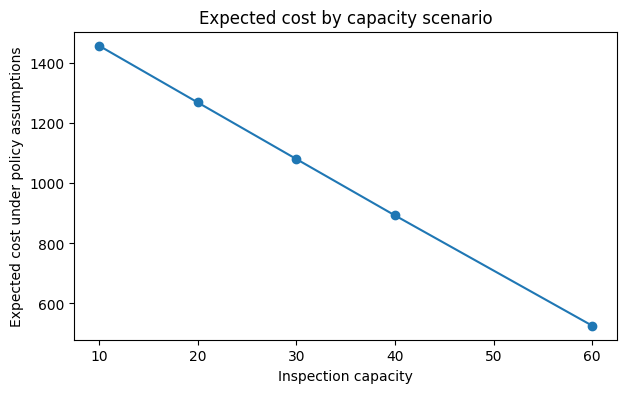

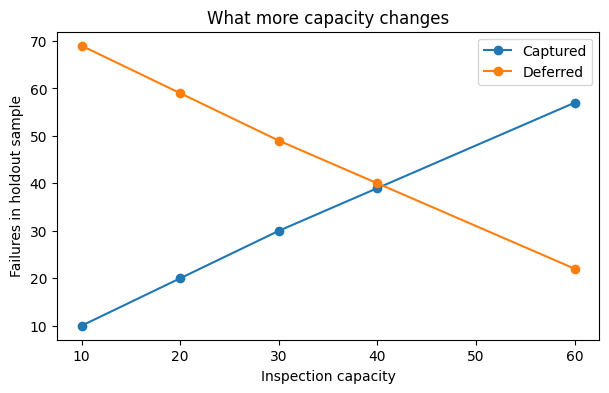

In [14]:
_, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    capacity_table["capacity"],
    capacity_table["total_expected_cost_under_policy_assumptions"],
    marker="o",
)
axis.set_xlabel("Inspection capacity")
axis.set_ylabel("Expected cost under policy assumptions")
axis.set_title("Expected cost by capacity scenario")
plt.show()

_, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    capacity_table["capacity"],
    capacity_table["actual_failures_captured"],
    marker="o",
    label="Captured",
)
axis.plot(
    capacity_table["capacity"],
    capacity_table["actual_failures_deferred"],
    marker="o",
    label="Deferred",
)
axis.set_xlabel("Inspection capacity")
axis.set_ylabel("Failures in holdout sample")
axis.set_title("What more capacity changes")
axis.legend()
plt.show()

## Turn the queue into a simple triage rule

The model only ranks risk. The action labels come from an operating rule.

Inspect now means the machine fits inside today's inspection capacity.
Expedite next means it falls just below today's line but remains inside a small high risk buffer.
Monitor means it stays in the ranked backlog for later review.

In [15]:
triage_queue = risk_queue.copy()
triage_queue["action"] = "Monitor"

triage_queue.loc[
    triage_queue["queue_rank"] <= daily_inspection_capacity,
    "action",
] = "Inspect now"

triage_queue.loc[
    (
        (triage_queue["queue_rank"] > daily_inspection_capacity)
        & (triage_queue["queue_rank"] <= daily_inspection_capacity + expedite_slots)
        & triage_queue["is_high_risk"]
    ),
    "action",
] = "Expedite next"

inspect_now_count = int((triage_queue["action"] == "Inspect now").sum())
expedite_next_count = int((triage_queue["action"] == "Expedite next").sum())
remaining_high_risk_backlog_count = int(
    ((triage_queue["action"] == "Monitor") & triage_queue["is_high_risk"]).sum()
)

triage_queue.head(20)

,machine_id,predicted_failure_probability,actual_failure,queue_rank,is_high_risk,action
0,885,0.998,1,1,True,Inspect now
1,914,0.998,1,2,True,Inspect now
2,848,0.998,1,3,True,Inspect now
3,445,0.997,1,4,True,Inspect now
4,411,0.997,1,5,True,Inspect now
5,841,0.997,1,6,True,Inspect now
6,524,0.996,1,7,True,Inspect now
7,611,0.996,1,8,True,Inspect now
8,480,0.996,1,9,True,Inspect now
9,668,0.996,1,10,True,Inspect now


## Final decision readout

The notebook ends with a compact operating summary.

It separates the high risk pool, today’s inspection group, the expedited next group, and the remaining backlog.

In [16]:
current_capacity_row = capacity_table.loc[
    capacity_table["capacity"] == daily_inspection_capacity
].iloc[0]

final_readout = pd.DataFrame(
    {
        "question": [
            "Selected model",
            "Operating high risk cutoff",
            "Machines in high risk pool",
            "Labeled failures in high risk pool",
            f"Machines inspected today at capacity {daily_inspection_capacity}",
            "Machines expedited next",
            "High risk machines left in backlog",
            "Deferred labeled failures in holdout",
        ],
        "answer": [
            selected_model_name,
            round(operating_high_risk_cutoff, 6),
            high_risk_machine_count,
            high_risk_failures_in_holdout,
            inspect_now_count,
            expedite_next_count,
            remaining_high_risk_backlog_count,
            int(current_capacity_row["actual_failures_deferred"]),
        ],
    }
)

display(final_readout.style.set_properties(subset=["question"], **{"white-space": "normal"}))

,question,answer
0,Selected model,Gradient Boosting
1,Operating high risk cutoff,0.924677
2,Machines in high risk pool,65
3,Labeled failures in high risk pool,62
4,Machines inspected today at capacity 10,10
5,Machines expedited next,5
6,High risk machines left in backlog,50
7,Deferred labeled failures in holdout,69


## Limits and next upgrades

This notebook is a ranking and queue tool. It is not a full maintenance optimization system.

What it does well

It ranks machines by predicted failure risk.
It chooses an operating cutoff from validation data.
It measures queue quality where action happens.
It shows how limited inspection capacity changes what gets caught or deferred.

What it does not claim

It does not estimate exact failure timing.
It does not create true urgency classes.
It does not optimize staffing.
It does not prove causal relationships between input variables and failure.

Best next upgrades

Add probability calibration.
Use time based validation if future data supports it.
Replace policy cost inputs with real business cost estimates.
Add failure timing or maintenance history if those fields become available.